# Nonlinear unmixing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
from utils import gaussian_function, compute_rmse, compute_fcls
from viz import plot_endmember_spectral_signatures, plot_linear_regression_and_bland_altman

## Generate synthetic endmember spectra

In [3]:
nb_wavelengths = 50
wavelengths = np.linspace(400, 2500, nb_wavelengths)

# Vegetation: red-edge rise, NIR plateau
vegetation = (
    gaussian_function(x=wavelengths, a=0.4, b=550, c=40) + 
    gaussian_function(x=wavelengths, a=0.5, b=800, c=200) - 
    gaussian_function(x=wavelengths, a=0.15, b=670, c=20)
)
vegetation = np.clip(vegetation, 0, 1)

# Soil: broad bright curve
soil = 0.1 + 0.6 * ((wavelengths - 400) / 2100) ** 0.6
soil = np.clip(soil, 0, 1)

# Water: dark, absorption at NIR
water = 0.05 * np.exp(-((wavelengths - 400) / 400) ** 2)
water = np.clip(water, 0, 1)

nb_endmembers = 3
endmember_matrix = np.stack([vegetation, soil, water], axis=1)
labels = ["Vegetation", "Soil", "Water"]

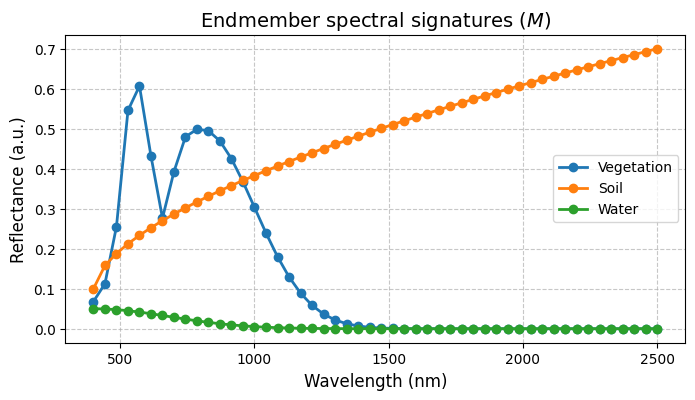

In [4]:
plot_endmember_spectral_signatures(endmember_matrix=endmember_matrix, wavelengths=wavelengths, labels=labels)    

## Simulate mixed pixels

$$\mathbf{r} = \mathbf{E}\mathbf{a} + \gamma \sum_{i<j} a_i a_j \left(\mathbf{e}_i \odot \mathbf{e}_j\right) + \boldsymbol{\varepsilon}$$

- $r: $ Reflectance vector (pixel spectrum)
- $E: $ Endmember matrix
- $a: $ Abundance vector
- $\gamma: $ Nonlinear interaction coefficient
- $e_i: $ Spectrum of endmember $i$
- $\odot: $ Element-wise (Hadamard) product
- $\varepsilon: $ Additive noise

In [5]:
def nonlinear_mix(
    endmember_matrix: np.ndarray,
    abundance_matrix: np.ndarray,
    gamma: float = 2.8,
    noise_std: float = 0.2
) -> np.ndarray:
    """
    Simulate mixed pixels.

    Args:
        endmember_matrix: Matrix of endmember spectra of shape (nb_wavelengths, nb_endmembers).
        abundance_matrix: Matrix of abundances of shape (n_pixels, nb_endmembers).
        gamma: Strength of the nonlinear interaction term.
        noise_std: Standard deviation of the additive Gaussian noise.

    Returns:
        Simulated reflectance matrix of shape (nb_pixels, nb_wavelengths).
        Each row corresponds to the reflectance spectrum of one pixel.
    """
    
    nb_endmembers = endmember_matrix.shape[1]
    
    # Linear term
    reflectance_linear = abundance_matrix @ endmember_matrix.T

    # Bilinear term (intimate mixing, mimicking the photon interactions between materials)
    reflectance_bilinear = np.zeros_like(reflectance_linear)
    for i in range(nb_endmembers):
        for j in range(i + 1, nb_endmembers):
            interaction = endmember_matrix[:, i] * endmember_matrix[:, j]
            coefficient = abundance_matrix[:, i] * abundance_matrix[:, j]
            reflectance_bilinear += np.outer(coefficient, interaction)

    reflectance = reflectance_linear + gamma * reflectance_bilinear

    # Noise term
    reflectance += np.random.normal(0, noise_std, reflectance.shape)

    # Ensure values are between 0 and 1        
    reflectance = np.clip(reflectance, 0, 1)
    
    return reflectance

In [6]:
nb_pixels = 800

# [Unknown] Abundances (summing to one, and within [O, 1]), of shape (nb_pixels, nb_endmembers)
abundance_map = np.random.dirichlet(alpha=[1, 1, 1], size=nb_pixels)

# [Known] Observed spectra, of shape (nb_pixels, nb_wavelengths)
observed_spectra = nonlinear_mix(endmember_matrix, abundance_map)

## Solution using linear unmixing (FCLS)

In [7]:
abundance_map_estimated_lu = np.zeros_like(abundance_map)
for i in range(nb_pixels):
    abundance_map_estimated_lu[i] = compute_fcls(spectrum=observed_spectra[i], M=endmember_matrix)
    
abundance_map_error_lu = abundance_map - abundance_map_estimated_lu

rmse_lu = compute_rmse(prediction=abundance_map_estimated_lu, ground_truth=abundance_map)
print(f"RMSE: {rmse_lu:.4f}")

RMSE: 0.1174


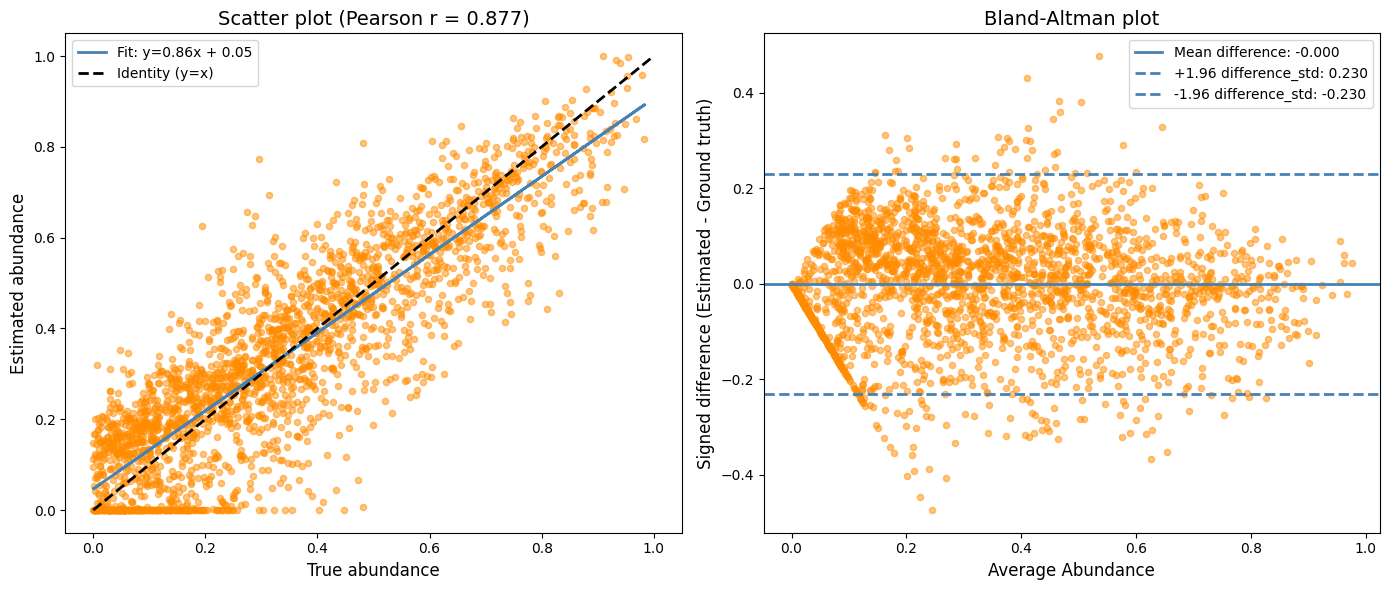

In [8]:
plot_linear_regression_and_bland_altman(abundance_map, abundance_map_estimated_lu)

## Solution using nonlinear unmixing (fan model)

In [9]:
def fan_model(a, M, gamma):
    """
    Compute the simulated reflectance spectrum of a mixed pixel using the forward Fan bilinear model.
    
    Args:
        a: Fractional abundance vector of shape (nb_endmembers,), non-negative and summing to 1.
        M: Endmember matrix, of shape (n_wavelengths, nb_endmembers).    
        E: Endmember matrix whose columns are pure material spectra,
           of shape (n_wavelengths, nb_endmembers).
        gamma: Strength of the bilinear interaction term, controlling the contribution of pairwise photon-scattering
            effects between materials. Use gamma=0 to recover standard linear unmixing. 

    Returns:
        Simulated reflectance spectrum of shape (n_wavelengths,), representing the mixed pixel signature under the Fan bilinear model.
    """
    nb_endmembers = M.shape[1]

    # linear term
    r = M @ a 

    # Nonlinear term
    for i in range(nb_endmembers):
        for j in range(i + 1, nb_endmembers):
            r += gamma * a[i] * a[j] * (M[:, i] * M[:, j])

    return r

In [10]:
def bilinear_unmixing(spectrum: np.ndarray, M: np.ndarray, gamma: float = 2.8) -> np.ndarray:
    """
    Apply bilinear unmixing using the Fan bilinear model.
    
    Args:
        spectrum: Observed spectral signature, of shape (n_wavelengths,).    
        M: Endmember matrix, of shape (n_wavelengths, nb_endmembers).    
        gamma: Strength of the bilinear interaction term, controlling the contribution of pairwise photon-scattering
            effects between materials. Use gamma=0 to recover standard linear unmixing. 

    Returns:
        Estimated fractional abundances of shape (nb_endmembers,), non-negative and summing to 1.
    """
    nb_endmembers = M.shape[1]
    
    def objective(a):
        r_hat = fan_model(a, M, gamma)
        return np.sum((spectrum - r_hat) ** 2)
    
    # Constraints: sum-to-one, non-negativity
    constraints = {"type": "eq", "fun": lambda a: a.sum() - 1}
    bounds = [(0, 1)] * nb_endmembers    
    
    result = minimize(
        objective,
        x0=np.ones(nb_endmembers) / nb_endmembers,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-9, "maxiter": 200})
    
    return result.x

In [11]:
abundance_map_estimated_nlu = np.zeros_like(abundance_map)
for i in range(nb_pixels):
    abundance_map_estimated_nlu[i] = bilinear_unmixing(spectrum=observed_spectra[i], M=endmember_matrix)

abundance_map_error_nlu = abundance_map - abundance_map_estimated_nlu
    
rmse_nlu = compute_rmse(prediction=abundance_map_estimated_nlu, ground_truth=abundance_map)
print(f"RMSE: {rmse_nlu:.4f}")

RMSE: 0.0955


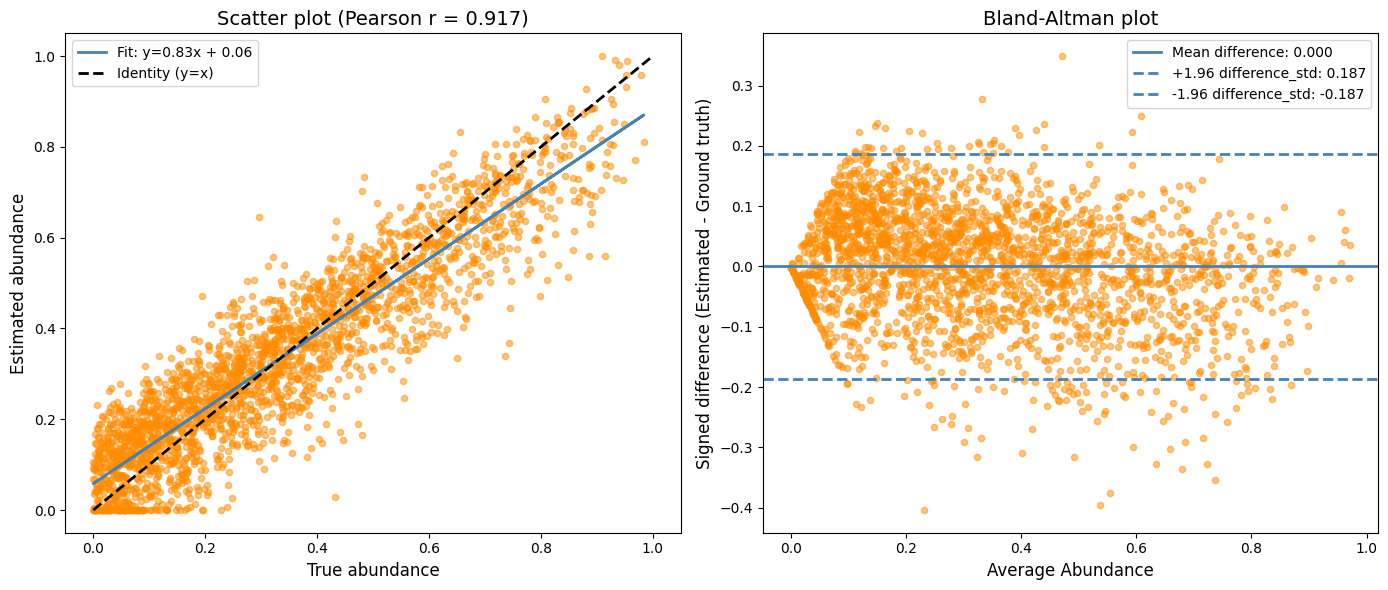

In [12]:
plot_linear_regression_and_bland_altman(abundance_map, abundance_map_estimated_nlu)